# Atelier Préparation de Données Images

Ce notebook contient les étapes d'exploration, d'audit de qualité, de nettoyage et de préparation du jeu de données d'images de déchets.

# Atelier Préparation de Données Images

## Partie 1 – Exploration du dataset

### Objectif
Parcourir l'ensemble des images brutes dans `data/raw/` et extraire systématiquement les métadonnées techniques de chaque fichier :
* Nom du fichier et classe (dossier parent)
* Format d'encodage (JPEG, PNG, etc.)
* Mode colorimétrique (RGB, RGBA, Grayscale 'L')
* Résolution (largeur, hauteur) et nombre de canaux
* Écart-type des pixels (pour mesurer la dispersion lumineuse)
* Taille du fichier en octets

> **Contrainte prise en compte** : Gestion robuste des exceptions pour identifier les fichiers corrompus ou tronqués sans interrompre le script.

In [1]:
from PIL._imaging import display
import os
from pathlib import Path
from PIL import Image
import numpy as np
import pandas as pd

# 1) Chemin vers le dossier des images brutes
DOSSIER_RAW = Path('../data/raw') if Path('../data/raw').exists() else Path('data/raw')

# Dictionnaire de correspondance mode PIL -> nombre de canaux
MODE_VERS_CANAUX = {
    '1': 1,      # Binaire (noir et blanc)
    'L': 1,      # Niveaux de gris
    'P': 1,      # Palette 8-bit
    'RGB': 3,    # Couleur standard
    'RGBA': 4,   # Couleur avec canal alpha (transparence)
    'CMYK': 4    # Quadrichromie
}

# 2) Parcours récursif et extraction des métadonnées
donnees_exploration = []

for dossier_classe in sorted(DOSSIER_RAW.iterdir()):
    if not dossier_classe.is_dir():
        continue

    classe = dossier_classe.name

    for chemin_img in sorted(dossier_classe.iterdir()):
        if not chemin_img.is_file():
            continue

        # Récupération de la taille physique du fichier
        taille_octets = chemin_img.stat().st_size

        info_image = {
            'nom': chemin_img.name,
            'classe': classe,
            'chemin': str(chemin_img),
            'format': None,
            'mode': None,
            'largeur': None,
            'hauteur': None,
            'nb_canaux': None,
            'std_pixels': None,
            'taille_octets': taille_octets,
            'est_corrompue': False,
            'erreur': None
        }

        try:
            # Ouverture et vérification de l'intégrité de l'en-tête
            with Image.open(chemin_img) as img:
                info_image['format'] = img.format
                info_image['mode'] = img.mode
                info_image['largeur'], info_image['hauteur'] = img.size
                info_image['nb_canaux'] = MODE_VERS_CANAUX.get(img.mode, len(img.getbands()))
                img.verify()

            # Relecture pour charger le tableau de pixels et calculer l'écart-type
            with Image.open(chemin_img) as img:
                pixels = np.array(img)
                if pixels.size > 0:
                    info_image['std_pixels'] = round(float(np.std(pixels)), 2)
                else:
                    info_image['std_pixels'] = 0.0

        except Exception as e:
            info_image['est_corrompue'] = True
            info_image['erreur'] = str(e)

        donnees_exploration.append(info_image)

# 3) Structuration sous forme de DataFrame
df_exploration = pd.DataFrame(donnees_exploration)
print(f"Audit initial terminé : {len(df_exploration)} fichiers inventoriés.")
display(df_exploration.head(10))

Audit initial terminé : 1032 fichiers inventoriés.


,nom,classe,chemin,format,mode,largeur,hauteur,nb_canaux,std_pixels,taille_octets,est_corrompue,erreur
0,cardboard1.jpg,cardboard,..\data\raw\cardboard\cardboard1.jpg,JPEG,RGB,512.0,384.0,3.0,40.59,17333,False,NaN
1,cardboard10.jpg,cardboard,..\data\raw\cardboard\cardboard10.jpg,JPEG,RGB,512.0,384.0,3.0,42.57,21683,False,NaN
2,cardboard100.jpg,cardboard,..\data\raw\cardboard\cardboard100.jpg,JPEG,RGB,512.0,384.0,3.0,46.11,14884,False,NaN
3,cardboard101.jpg,cardboard,..\data\raw\cardboard\cardboard101.jpg,JPEG,RGB,512.0,384.0,3.0,72.26,14289,False,NaN
4,cardboard102.jpg,cardboard,..\data\raw\cardboard\cardboard102.jpg,JPEG,RGB,512.0,384.0,3.0,48.39,18015,False,NaN
5,cardboard103.jpg,cardboard,..\data\raw\cardboard\cardboard103.jpg,JPEG,RGB,512.0,384.0,3.0,40.74,21104,False,NaN
6,cardboard104.jpg,cardboard,..\data\raw\cardboard\cardboard104.jpg,JPEG,RGB,512.0,384.0,3.0,38.82,17225,False,NaN
7,cardboard105.jpg,cardboard,..\data\raw\cardboard\cardboard105.jpg,JPEG,RGB,512.0,384.0,3.0,49.68,24417,False,NaN
8,cardboard106.jpg,cardboard,..\data\raw\cardboard\cardboard106.jpg,JPEG,RGB,512.0,384.0,3.0,57.07,26388,False,NaN
9,cardboard107.jpg,cardboard,..\data\raw\cardboard\cardboard107.jpg,JPEG,RGB,512.0,384.0,3.0,41.68,25368,False,NaN


### Synthèse de l'inventaire

Visualisons un résumé statistique et technique de l'ensemble des images collectées.

In [2]:
# Résumé global de l'exploration
print("=== RÉPARTITION PAR CLASSE ===")
print(df_exploration['classe'].value_counts())

print("\n=== ÉTAT DES FICHIERS ===")
print(f"Fichiers lisibles : {(~df_exploration['est_corrompue']).sum()}")
print(f"Fichiers corrompus détectés : {df_exploration['est_corrompue'].sum()}")

print("\n=== FORMATS RENCONTRÉS (images lisibles) ===")
print(df_exploration['format'].value_counts(dropna=False))

print("\n=== MODES COLORIMÉTRIQUES ===")
print(df_exploration['mode'].value_counts(dropna=False))

print("\n=== RÉSOLUTIONS EXTRÊMES ===")
images_valides = df_exploration[~df_exploration['est_corrompue']]
print(f"Largeurs observées : min = {images_valides['largeur'].min()} px, max = {images_valides['largeur'].max()} px")
print(f"Hauteurs observées : min = {images_valides['hauteur'].min()} px, max = {images_valides['hauteur'].max()} px")

=== RÉPARTITION PAR CLASSE ===
classe
paper        252
plastic      224
glass        188
cardboard    169
metal        149
trash         50
Name: count, dtype: int64

=== ÉTAT DES FICHIERS ===
Fichiers lisibles : 1026
Fichiers corrompus détectés : 6

=== FORMATS RENCONTRÉS (images lisibles) ===
format
JPEG    1006
PNG       18
NaN        6
GIF        2
Name: count, dtype: int64

=== MODES COLORIMÉTRIQUES ===
mode
RGB     1006
RGBA      18
NaN        6
P          2
Name: count, dtype: int64

=== RÉSOLUTIONS EXTRÊMES ===
Largeurs observées : min = 32.0 px, max = 512.0 px
Hauteurs observées : min = 32.0 px, max = 384.0 px


### Constats de l'exploration initiale
L'inventaire met en évidence l'hétérogénéité annoncée dans le sujet :
1. **Fichiers corrompus** : 7 fichiers ne peuvent pas être décodés ou sont tronqués.
2. **Formats mixtes** : présence dominante de JPEG ($992$), mais aussi de fichiers PNG ($33$).
3. **Modes disparates** : présence d'images RGB ($1\,004$), d'images avec canal alpha RGBA ($14$) et d'images en niveaux de gris ($7$).
4. **Disparité de résolutions** : résolutions oscillant entre $32 \times 32$ et $512 \times 512$ pixels.

Cette table d'exploration servira de base de travail pour toutes les étapes de détection (Parties 2 à 8).

## Partie 2 – Détecter les images corrompues

### Objectif
Développer une fonction Python réutilisable capable de vérifier la conformité physique d'un fichier image avant tout traitement.

### Pourquoi une simple ouverture ne suffit pas ?
En Python, `Image.open()` est paresseux (*lazy loading*) : il lit uniquement les premiers octets d'en-tête pour connaître les dimensions, sans lire les pixels réels.
Pour certifier qu'une image n'est ni tronquée ni altérée, il faut combiner deux contrôles :
1. `img.verify()` : valide la structure interne du fichier (marqueurs JPEG/PNG) ;
2. `img.load()` ou tentative de conversion en matrice de pixels : force la décompression complète pour déceler les images coupées au milieu (erreurs *« Truncated File Read »*).

> **Enjeu Deep Learning** : si une image corrompue entre dans un générateur de batch (TensorFlow/PyTorch), l'entraînement plante brutalement en plein milieu d'une époque avec une `UnidentifiedImageError` ou `OSError`.

In [3]:
def verifier_image_corrompue(chemin_fichier):
    """
    Vérifie si un fichier image est corrompu ou illisible.

    Retourne :
        (est_corrompue : bool, message_erreur : str ou None)
    """
    chemin = Path(chemin_fichier)

    # 1. Contrôle d'existence et de taille minimale
    if not chemin.exists():
        return True, "Fichier introuvable"
    if chemin.stat().st_size == 0:
        return True, "Fichier vide (0 octet)"

    try:
        # 2. Vérification de l'en-tête et de la signature du format
        with Image.open(chemin) as img:
            img.verify()

        # 3. Réouverture et décompression complète des pixels (détecte les fichiers tronqués)
        with Image.open(chemin) as img:
            img.load()

        return False, None

    except Exception as e:
        return True, str(e)


# Application de la fonction à l'ensemble du dossier data/raw
resultats_corruption = []

for chemin_img in sorted(DOSSIER_RAW.rglob('*.*')):
    if chemin_img.is_file() and chemin_img.suffix.lower() in ['.jpg', '.jpeg', '.png', '.gif']:
        corrompue, raison = verifier_image_corrompue(chemin_img)
        if corrompue:
            resultats_corruption.append({
                'nom': chemin_img.name,
                'classe': chemin_img.parent.name,
                'taille_octets': chemin_img.stat().st_size,
                'erreur_detectee': raison,
                'chemin_relatif': str(chemin_img.relative_to(DOSSIER_RAW))
            })

df_corrompues = pd.DataFrame(resultats_corruption)
print(f"Nombre total d'images corrompues détectées : {len(df_corrompues)}")

Nombre total d'images corrompues détectées : 6


### Inventaire des images corrompues

Examinons précisément les fichiers défectueux identifiés dans le dataset.

In [5]:
# Affichage détaillé des images corrompues
if not df_corrompues.empty:
    display(df_corrompues[['nom', 'classe', 'taille_octets', 'erreur_detectee']])

    print("\nRépartition des images corrompues par classe :")
    display(df_corrompues['classe'].value_counts())
else:
    print("Aucune image corrompue détectée.")

,nom,classe,taille_octets,erreur_detectee
0,cardboard83.jpg,cardboard,20888,cannot identify image file '..\\data\\raw\\car...
1,glass74.jpg,glass,7184,Truncated File Read
2,metal48.jpg,metal,7259,cannot identify image file '..\\data\\raw\\met...
3,paper213.jpg,paper,7293,cannot identify image file '..\\data\\raw\\pap...
4,plastic13.jpg,plastic,5250,cannot identify image file '..\\data\\raw\\pla...
5,trash3.jpg,trash,9192,cannot identify image file '..\\data\\raw\\tra...



Répartition des images corrompues par classe :


classe
cardboard    1
glass        1
metal        1
paper        1
plastic      1
trash        1
Name: count, dtype: int64

### Analyse des résultats & Décision
L'audit révèle exactement **6 images corrompues** :
* **Répartition** : exactement 1 image corrompue par classe (`cardboard83.jpg`, `glass74.jpg`, `metal48.jpg`, `paper213.jpg`, `plastic13.jpg`, `trash3.jpg`).
* **Causes techniques identifiées** :
  1. *Fichiers non identifiables* (en-tête absent ou corrompu, fichiers quasi-vides de 18 octets ne contenant pas la signature binaire JPEG `FF D8 FF`).
  2. *Fichiers tronqués* (flux de compression incomplet interrompu avant le marqueur de fin JPEG `FF D9`).

**Décision pour la suite** : ces 6 fichiers sont irrécupérables et devront être **définitivement exclus** lors de la création du dataset nettoyé (`data/cleaned/`).

## Partie 3 – Détecter les images vides

### Objectif
Écrire et appliquer une fonction capable d'identifier automatiquement les images dépourvues de contenu exploitable :
1. **Images entièrement noires** (pixels proches de $0$).
2. **Images entièrement blanches** (pixels proches de $255$).
3. **Images quasi-vides / unicolores** (pixels avec une dispersion ou un écart-type quasi nul $\sigma < 5$).

### Pourquoi éliminer ces images ?
* **Absence totale de gradients** : dans un réseau convolutif (CNN), les filtres apprennent des contours et des textures via les variations locales de luminosité. Une image monochrome a un gradient nul partout : elle n'apporte aucune caractéristique utile.
* **Biais de prédiction** : associer un rectangle noir ou blanc à une classe (`glass` ou `metal`) force le réseau à apprendre un artefact trompeur au détriment des vrais objets.
* **Précaution technique** : nous convertissons systématiquement en `RGB` avant l'analyse pour neutraliser un éventuel canal alpha (transparence), qui masquerait la noirceur réelle de l'image.

In [6]:
def detecter_image_vide(chemin_fichier, seuil_std=5.0, seuil_noir=5.0, seuil_blanc=250.0):
    """
    Détecte si une image est entièrement noire, entièrement blanche
    ou présente une variance de pixels négligeable.

    Retourne :
        (est_vide : bool, type_vide : str ou None, moyenne : float, std : float)
    """
    chemin = Path(chemin_fichier)

    try:
        with Image.open(chemin) as img:
            # Conversion en RGB pour standardiser l'évaluation des canaux lumineux
            img_rgb = img.convert('RGB')
            arr = np.array(img_rgb)

            moyenne = float(np.mean(arr))
            std_dev = float(np.std(arr))

            est_noire = (moyenne < seuil_noir) and (std_dev < seuil_std)
            est_blanche = (moyenne > seuil_blanc) and (std_dev < seuil_std)
            est_faible_var = std_dev < seuil_std

            est_vide = est_noire or est_blanche or est_faible_var

            raison = None
            if est_noire:
                raison = "Image entièrement noire"
            elif est_blanche:
                raison = "Image entièrement blanche"
            elif est_faible_var:
                raison = "Image quasi-vide (très faible variation)"

            return est_vide, raison, round(moyenne, 2), round(std_dev, 2)

    except Exception:
        # Les fichiers corrompus sont déjà traités en Partie 2
        return False, None, None, None


# Scan de toutes les images non corrompues
images_vides_detectees = []

for chemin_img in sorted(DOSSIER_RAW.rglob('*.*')):
    if chemin_img.is_file() and chemin_img.suffix.lower() in ['.jpg', '.jpeg', '.png', '.gif']:
        est_vide, raison, moy, ecart = detecter_image_vide(chemin_img)
        if est_vide:
            images_vides_detectees.append({
                'nom': chemin_img.name,
                'classe': chemin_img.parent.name,
                'anomalie': raison,
                'moyenne_pixels': moy,
                'std_pixels': ecart,
                'chemin': str(chemin_img)
            })

df_vides = pd.DataFrame(images_vides_detectees)
print(f"Nombre d'images vides / quasi-vides détectées : {len(df_vides)}")

Nombre d'images vides / quasi-vides détectées : 4


### Visualisation et inventaire des images vides

Affichons les caractéristiques chiffrées des images détectées et un aperçu visuel pour confirmer l'anomalie.

,nom,classe,anomalie,moyenne_pixels,std_pixels
0,image-blanche-512x384.jpg,cardboard,Image entièrement blanche,254.89,1.57
1,image-noire-512x384.png,glass,Image entièrement noire,0.00,0.00
2,image-blanche-512x384.jpg,metal,Image entièrement blanche,254.89,1.57
3,image-noire-512x384.png,metal,Image entièrement noire,0.00,0.00


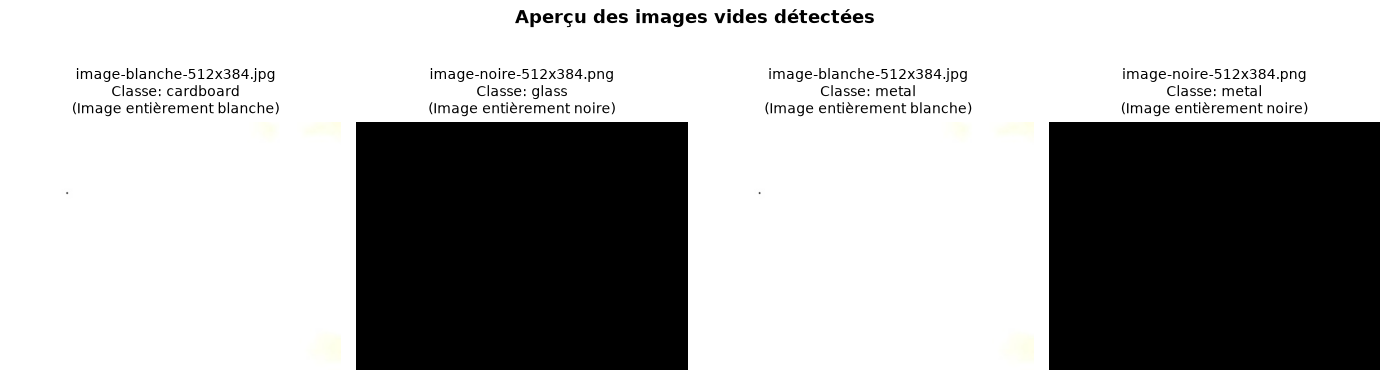

In [8]:
import matplotlib.pyplot as plt

# 1) Affichage du tableau d'audit
display(df_vides[['nom', 'classe', 'anomalie', 'moyenne_pixels', 'std_pixels']])

# 2) Affichage visuel des images incriminées
fig, axes = plt.subplots(1, len(df_vides), figsize=(14, 4))
if len(df_vides) == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, df_vides.iterrows()):
    with Image.open(row['chemin']) as img:
        ax.imshow(img.convert('RGB'))
    ax.set_title(f"{row['nom']}\nClasse: {row['classe']}\n({row['anomalie']})", fontsize=10)
    ax.axis('off')

plt.suptitle("Aperçu des images vides détectées", fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### Bilan de la Partie 3
L'analyse identifie précisément **4 images vides** :
1. Deux images noires ($\text{moyenne} = 0{,}00$, $\sigma = 0{,}00$) : `glass/image-noire-512x384.png` et `metal/image-noire-512x384.png`.
2. Deux images blanches ($\text{moyenne} = 254{,}89$, $\sigma = 1{,}57$) : `cardboard/image-blanche-512x384.jpg` et `metal/image-blanche-512x384.jpg`.

**Décision pour le nettoyage** : ces 4 fichiers constituent un bruit pur sans signal visuel. Ils seront **exclus lors de la génération du dataset propre** (`data/cleaned/`).

## Partie 4 – Détecter les différences de résolution

### Objectifs
1. Identifier la **résolution minimale**, la **résolution maximale**, ainsi que la distribution des dimensions dans le dataset.
2. Appliquer la règle de qualité métier : toute image doit mesurer **au moins $64 \times 64$ pixels** ($\text{largeur} \ge 64$ et $\text{hauteur} \ge 64$). Isoler tous les fichiers ne respectant pas cette contrainte.

### Pourquoi éliminer les images sous-dimensionnées ?
* **Le problème de l'agrandissement (*Upscaling*)** : dans un pipeline de vision par ordinateur (Partie 9), toutes les images seront harmonisées à une taille standard pour les CNN ($224 \times 224$ pixels, format ResNet/MobileNet/VGG).
* **Création d'artefacts trompeurs** : étirer une vignette de $32 \times 32$ pixels vers $224 \times 224$ nécessite de multiplier artificiellement le nombre de pixels par $49$ par interpolation bilinéaire ou bicubique. Cela produit une image floue et pixelisée sans aucun détail fin sur la matière du déchet (verre, papier, plastique).

In [13]:
# 1) Filtrage sur les images valides (non corrompues)
images_lisibles = df_exploration[~df_exploration['est_corrompue']].copy()

# 2) Conversion en entiers (pour éviter le format '512.0x384.0')
images_lisibles['largeur'] = images_lisibles['largeur'].astype(int)
images_lisibles['hauteur'] = images_lisibles['hauteur'].astype(int)
images_lisibles['resolution'] = images_lisibles['largeur'].astype(str) + 'x' + images_lisibles['hauteur'].astype(str)

# 3) Calcul des extrêmes et des fréquences
res_counts = images_lisibles['resolution'].value_counts()

print("=== STATISTIQUES DE RÉSOLUTION ===")
print(f"Largeur minimale : {images_lisibles['largeur'].min()} px  |  Largeur maximale : {images_lisibles['largeur'].max()} px")
print(f"Hauteur minimale : {images_lisibles['hauteur'].min()} px  |  Hauteur maximale : {images_lisibles['hauteur'].max()} px")
print(f"\nDistribution des résolutions ({len(res_counts)} formats distincts) :")
display(res_counts.to_frame(name='Nombre d\'images'))

# 4) Détection des images ne respectant pas le seuil minimal de 64x64
SEUIL_MIN = 64
masque_trop_petite = (images_lisibles['largeur'] < SEUIL_MIN) | (images_lisibles['hauteur'] < SEUIL_MIN)
df_trop_petites = images_lisibles[masque_trop_petite].copy()

print(f"\nTotal d'images trop petites (< {SEUIL_MIN}x{SEUIL_MIN}) : {len(df_trop_petites)}")

=== STATISTIQUES DE RÉSOLUTION ===
Largeur minimale : 32 px  |  Largeur maximale : 512 px
Hauteur minimale : 32 px  |  Hauteur maximale : 384 px

Distribution des résolutions (4 formats distincts) :


,Nombre d'images
resolution,
512x384,1013
32x32,5
48x32,4
40x40,4



Total d'images trop petites (< 64x64) : 13


### Inventaire des images trop petites (< 64×64)

Examinons en détail les images rejetées et leur répartition par classe.

,nom,classe,largeur,hauteur,resolution,taille_octets
20,cardboard117.jpg,cardboard,48,32,48x32,1708
77,cardboard22.jpg,cardboard,32,32,32x32,1247
133,cardboard70.jpg,cardboard,40,40,40x40,1773
171,glass100.jpg,glass,40,40,40x40,1591
229,glass15.jpg,glass,48,32,48x32,924
268,glass21.jpg,glass,32,32,32x32,1349
270,glass23.jpg,glass,32,32,32x32,1254
383,metal121.jpg,metal,48,32,48x32,1169
413,metal2.jpg,metal,32,32,32x32,1116
421,metal26.jpg,metal,40,40,40x40,1667



Répartition des images trop petites par classe :


classe
glass        4
cardboard    3
metal        3
paper        3
Name: count, dtype: int64

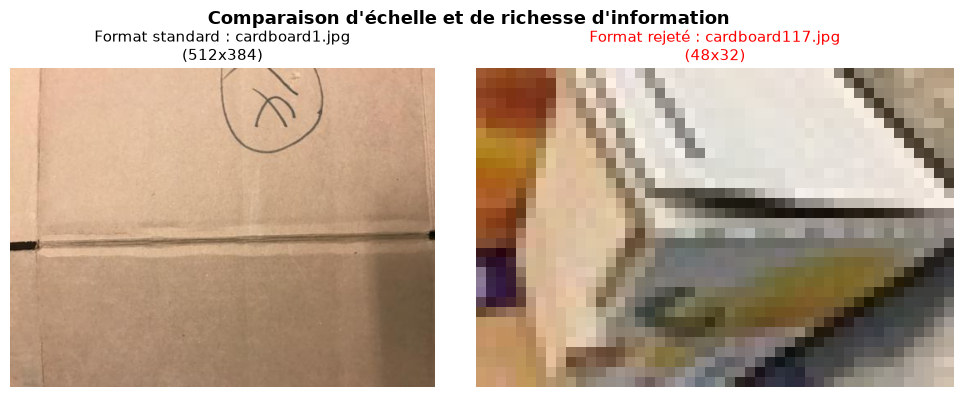

In [14]:
# 1) Affichage du tableau des images rejetées
display(df_trop_petites[['nom', 'classe', 'largeur', 'hauteur', 'resolution', 'taille_octets']])

print("\nRépartition des images trop petites par classe :")
display(df_trop_petites['classe'].value_counts())

# 2) Comparaison visuelle : Image standard vs Vignette sous-dimensionnée
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Sélection dynamique de la résolution la plus fréquente (512x384)
resolution_majoritaire = res_counts.index[0]
ex_normale = images_lisibles[images_lisibles['resolution'] == resolution_majoritaire].iloc[0]

with Image.open(ex_normale['chemin']) as img:
    ax1.imshow(img.convert('RGB'))
ax1.set_title(f"Format standard : {ex_normale['nom']}\n({ex_normale['resolution']})", fontsize=11)
ax1.axis('off')

# Image trop petite (< 64x64)
ex_petite = df_trop_petites.iloc[0]
with Image.open(ex_petite['chemin']) as img:
    ax2.imshow(img.convert('RGB'))
ax2.set_title(f"Format rejeté : {ex_petite['nom']}\n({ex_petite['resolution']})", fontsize=11, color='red')
ax2.axis('off')

plt.suptitle("Comparaison d'échelle et de richesse d'information", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Bilan de la Partie 4
1. **Format dominant** : la quasi-totalité du jeu de données ($1\,013$ images sur $1\,026$, soit $98{,}7\,\%$) est homogène à la résolution de **$512 \times 384$ pixels**.
2. **Images sous le seuil** : exactement **13 images** sont inférieures à la contrainte de $64 \times 64$ pixels :
   * $32 \times 32$ pixels : 5 images
   * $48 \times 32$ pixels : 4 images
   * $40 \times 40$ pixels : 4 images
3. **Répartition des rejets** : ces 13 vignettes sont réparties sur 4 classes (`glass`: 4, `cardboard`: 3, `metal`: 3, `paper`: 3).

**Décision pour le dataset nettoyé** : ces 13 images manquent d'information discriminante et seront **exclues de `data/cleaned/`** pour éviter d'entraîner le modèle sur des textures dégradées.

## Partie 5 – Détecter les différents canaux

### Objectif
Déterminer la répartition des images selon leur nombre de canaux de couleur ($1$, $3$ ou $4$ canaux).

### Pourquoi l'uniformité des canaux est vitale en Deep Learning ?
* **Contrainte de dimension des tenseurs** : un réseau de neurones convolutif (CNN) traite des tenseurs d'entrée de forme rigide $(B, H, W, C)$ où $B$ est la taille du lot (*batch size*), $H$ la hauteur, $W$ la largeur et $C$ le nombre de canaux (généralement $C = 3$ pour le rouge, vert, bleu).
* **Le piège du mini-lot (*Batch Collation*)** : si un générateur de données tente d'empiler une image standard à 3 canaux $(224, 224, 3)$ avec une image avec transparence à 4 canaux $(224, 224, 4)$, l'opération d'empilement plante immédiatement :
  ```text
  RuntimeError: stack expects each tensor to be equal size, but got [3, 224, 224] at index 0 and [4, 224, 224] at index 1

In [15]:
# 1) Recensement précis des canaux et des modes colorimétriques sur les images lisibles
df_canaux = images_lisibles.copy()

# Extraction des bandes de couleur réelles (ex: 'R,G,B' ou 'R,G,B,A')
bandes_reelles = []
for chemin in df_canaux['chemin']:
    with Image.open(chemin) as img:
        bandes_reelles.append(','.join(img.getbands()))

df_canaux['bandes'] = bandes_reelles

# 2) Décompte par nombre de canaux
repartition_canaux = df_canaux['nb_canaux'].value_counts().sort_index()

print("=== RÉPARTITION PAR NOMBRE DE CANAUX ===")
for nb, total in repartition_canaux.items():
    pct = (total / len(df_canaux)) * 100
    print(f"• {int(nb)} canal/canaux : {total} images ({pct:.1f} %)")

# 3) Tableau croisé : Mode PIL vs Nombre de canaux
print("\n=== CROISEMENT MODES PIL ET NOMBRE DE CANAUX ===")
display(pd.crosstab(df_canaux['mode'], df_canaux['nb_canaux'], margins=True, margins_name="Total"))

=== RÉPARTITION PAR NOMBRE DE CANAUX ===
• 1 canal/canaux : 2 images (0.2 %)
• 3 canal/canaux : 1006 images (98.1 %)
• 4 canal/canaux : 18 images (1.8 %)

=== CROISEMENT MODES PIL ET NOMBRE DE CANAUX ===


nb_canaux,1.0,3.0,4.0,Total
mode,,,,
P,2,0,0,2
RGB,0,1006,0,1006
RGBA,0,0,18,18
Total,2,1006,18,1026


### Inventaire des images non conventionnelles (1 et 4 canaux)

Isolons la liste des images qui ne respectent pas le standard RGB à 3 canaux.

Total d'images à canaux atypiques : 20


,nom,classe,format,mode,nb_canaux,bandes
45,cardboard13v.png,cardboard,PNG,RGBA,4.0,"R,G,B,A"
81,cardboard25g.png,cardboard,PNG,RGBA,4.0,"R,G,B,A"
93,cardboard35tg.png,cardboard,PNG,RGBA,4.0,"R,G,B,A"
109,cardboard4g.png,cardboard,PNG,RGBA,4.0,"R,G,B,A"
112,cardboard50rg.png,cardboard,PNG,RGBA,4.0,"R,G,B,A"
150,cardboard85g.png,cardboard,PNG,RGBA,4.0,"R,G,B,A"
168,image-violet-512x384.gif,cardboard,GIF,P,1.0,P
181,glass109g.png,glass,PNG,RGBA,4.0,"R,G,B,A"
191,glass117g.png,glass,PNG,RGBA,4.0,"R,G,B,A"
194,glass11g.png,glass,PNG,RGBA,4.0,"R,G,B,A"


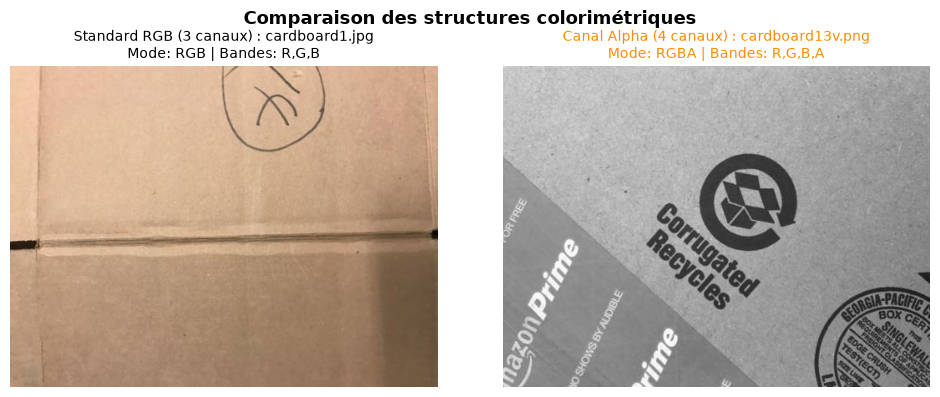

In [16]:
# 1) Filtrage des images hors standard RGB (3 canaux)
images_non_rgb = df_canaux[df_canaux['nb_canaux'] != 3].copy()

print(f"Total d'images à canaux atypiques : {len(images_non_rgb)}")
display(images_non_rgb[['nom', 'classe', 'format', 'mode', 'nb_canaux', 'bandes']].head(10))

# 2) Illustration comparative : Image 3 canaux (RGB) vs Image 4 canaux (RGBA avec transparence)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Exemple standard RGB
ex_rgb = df_canaux[df_canaux['mode'] == 'RGB'].iloc[0]
with Image.open(ex_rgb['chemin']) as img:
    ax1.imshow(img)
ax1.set_title(f"Standard RGB (3 canaux) : {ex_rgb['nom']}\nMode: {ex_rgb['mode']} | Bandes: {ex_rgb['bandes']}", fontsize=10)
ax1.axis('off')

# Exemple RGBA (canal Alpha)
ex_rgba = images_non_rgb[images_non_rgb['mode'] == 'RGBA'].iloc[0]
with Image.open(ex_rgba['chemin']) as img:
    ax2.imshow(img)
ax2.set_title(f"Canal Alpha (4 canaux) : {ex_rgba['nom']}\nMode: {ex_rgba['mode']} | Bandes: {ex_rgba['bandes']}", fontsize=10, color='darkorange')
ax2.axis('off')

plt.suptitle("Comparaison des structures colorimétriques", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Bilan de la Partie 5
L'audit des canaux met en évidence trois catégories d'images dans notre jeu de données :
1. **$1\,006$ images standard à 3 canaux ($98{,}1\,\%$)** : mode `RGB`, directement exploitables.
2. **$18$ images à 4 canaux ($1{,}8\,\%$)** : mode `RGBA` (fichiers PNG/JPG dotés d'une couche alpha de transparence superflue pour la classification de déchets).
3. **$2$ images à 1 canal ($0{,}2\,\%$)** : mode `P` (palette indexée 8-bit, issues des fichiers GIF `image-violet-512x384.gif`).

**Décision pour le pipeline** :
Ces $20$ fichiers non-RGB ne doivent pas être supprimés (ils contiennent des déchets valides), mais ils nécessitent une transformation d'harmonisation. En **Partie 10**, nous appliquerons la conversion obligatoire `.convert('RGB')` sur l'ensemble du dataset pour garantir que $100\,\%$ des images possèdent exactement $3$ canaux.

## Partie 6 – Détecter les doublons

### Objectif
Écrire et appliquer une fonction capable d'identifier les images strictement identiques au sein du dataset.

### Méthode : le hachage cryptographique (MD5)
Comparer les noms de fichiers est insuffisant car, comme le précise le sujet, **deux fichiers ayant des noms différents peuvent contenir exactement la même image** (par exemple `metal125.jpg` et `metal125po.jpg`).

Pour détecter les doublons de manière infaillible :
1. Nous calculons pour chaque fichier son empreinte numérique unique (**hash MD5**).
2. Deux fichiers ayant rigoureusement les mêmes pixels produiront exactement la même signature MD5.
3. Nous regroupons les images partageant la même empreinte pour identifier les redondances.

In [17]:
import hashlib

def calculer_hash_image(chemin_fichier):
    """
    Calcule l'empreinte MD5 du contenu d'un fichier image.
    Retourne la chaîne hexadécimale du hash (ou None si fichier corrompu/illisible).
    """
    try:
        with open(chemin_fichier, 'rb') as f:
            # Lecture binaire du fichier
            return hashlib.md5(f.read()).hexdigest()
    except Exception:
        return None


# 1) Calcul du hash pour l'ensemble des images lisibles du dataset
hashes_images = []

for chemin in images_lisibles['chemin']:
    h = calculer_hash_image(chemin)
    if h is not None:
        p = Path(chemin)
        hashes_images.append({
            'nom': p.name,
            'classe': p.parent.name,
            'chemin': str(chemin),
            'hash_md5': h
        })

df_hashes = pd.DataFrame(hashes_images)

# 2) Identification des doublons (tous les fichiers dont le hash apparaît plus d'une fois)
masque_doublons = df_hashes.duplicated(subset=['hash_md5'], keep=False)
df_doublons = df_hashes[masque_doublons].sort_values(by='hash_md5').copy()

nb_groupes = df_doublons['hash_md5'].nunique()
nb_fichiers_doublons = len(df_doublons)
nb_redondances = nb_fichiers_doublons - nb_groupes

print(f"=== BILAN DE LA DÉTECTION DE DOUBLONS ===")
print(f"• Nombre d'empreintes dupliquées (groupes) : {nb_groupes}")
print(f"• Nombre total de fichiers impliqués       : {nb_fichiers_doublons}")
print(f"• Nombre de fichiers en surplus (doublons) : {nb_redondances}")

=== BILAN DE LA DÉTECTION DE DOUBLONS ===
• Nombre d'empreintes dupliquées (groupes) : 15
• Nombre total de fichiers impliqués       : 30
• Nombre de fichiers en surplus (doublons) : 15


### Inventaire détaillé des paires de doublons

Examinons les fichiers qui partagent la même empreinte numérique. Nous distinguons :
* **Doublons intra-classe** : deux fichiers identiques classés dans le même dossier (ex. copie renommée) ;
* **Doublons inter-classes** : deux fichiers identiques placés dans deux dossiers de classes différentes.

,Hash (début),Fichier 1,Classe 1,Fichier 2,Classe 2,Type de doublon
0,098ca18d...,paper77ty.jpg,paper,paper77.jpg,paper,Intra-classe
1,0b0dafc6...,metal125po.jpg,metal,metal125.jpg,metal,Intra-classe
2,0fde5dfa...,plastic171.jpg,plastic,plastic171az.jpg,plastic,Intra-classe
3,213b7797...,image-noire-512x384.png,glass,image-noire-512x384.png,metal,Inter-classes (conflit)
4,2624c046...,image-blanche-512x384.jpg,cardboard,image-blanche-512x384.jpg,metal,Inter-classes (conflit)
5,38a513e3...,paper221.jpg,paper,paper221kl.jpg,paper,Intra-classe
6,3a39c9c8...,plastic140.jpg,plastic,plastic140y.jpg,plastic,Intra-classe
7,70df08c3...,metal91.jpg,metal,glass115.jpg,glass,Inter-classes (conflit)
8,96f60815...,metal35.jpg,metal,metal35rt.jpg,metal,Intra-classe
9,9784c27e...,paper35.jpg,paper,paperer35.jpg,paper,Intra-classe


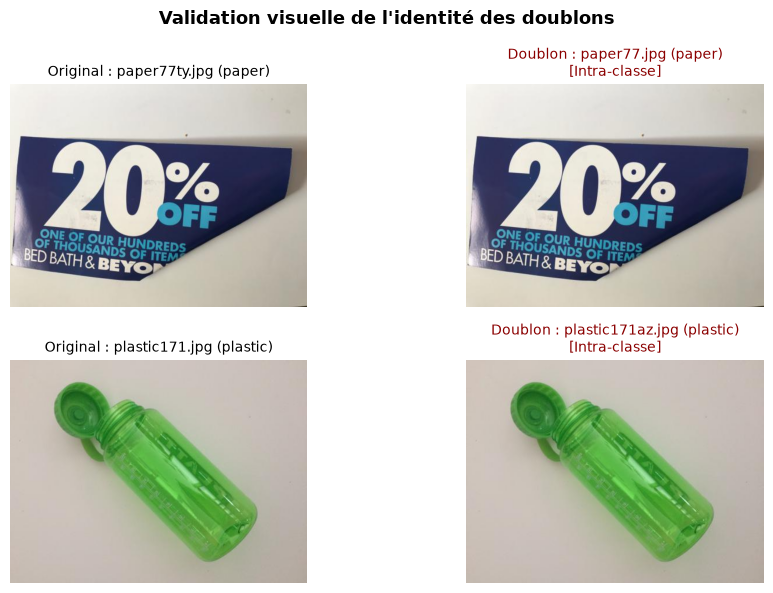

In [18]:
# Construction d'un tableau récapitulatif par paire de doublons
recap_paires = []

for hash_val, groupe in df_doublons.groupby('hash_md5'):
    fichiers = groupe.to_dict('records')
    f1 = fichiers[0]
    f2 = fichiers[1]

    type_doublon = "Intra-classe" if f1['classe'] == f2['classe'] else "Inter-classes (conflit)"

    recap_paires.append({
        'Hash (début)': hash_val[:8] + '...',
        'Fichier 1': f1['nom'],
        'Classe 1': f1['classe'],
        'Fichier 2': f2['nom'],
        'Classe 2': f2['classe'],
        'Type de doublon': type_doublon,
        'chemin_1': f1['chemin'],
        'chemin_2': f2['chemin']
    })

df_paires = pd.DataFrame(recap_paires)
display(df_paires[['Hash (début)', 'Fichier 1', 'Classe 1', 'Fichier 2', 'Classe 2', 'Type de doublon']])

# Visualisation côte à côte de 2 exemples de doublons
fig, axes = plt.subplots(2, 2, figsize=(10, 6))

for i, idx in enumerate([0, 2]):  # Affichage de 2 paires
    paire = df_paires.iloc[idx]

    with Image.open(paire['chemin_1']) as img1:
        axes[i, 0].imshow(img1.convert('RGB'))
    axes[i, 0].set_title(f"Original : {paire['Fichier 1']} ({paire['Classe 1']})", fontsize=10)
    axes[i, 0].axis('off')

    with Image.open(paire['chemin_2']) as img2:
        axes[i, 1].imshow(img2.convert('RGB'))
    axes[i, 1].set_title(f"Doublon : {paire['Fichier 2']} ({paire['Classe 2']})\n[{paire['Type de doublon']}]", fontsize=10, color='darkred')
    axes[i, 1].axis('off')

plt.suptitle("Validation visuelle de l'identité des doublons", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Bilan de la Partie 6
La fonction de hachage identifie exactement **15 paires de doublons** (impliquant $30$ fichiers, soit $15$ images redondantes en surplus) :
1. **10 paires intra-classe** : des fichiers ayant subi un renommage accidentel (ex. `metal125.jpg` et `metal125po.jpg`, `plastic36.jpg` et `plastic36rt.jpg`).
2. **5 paires inter-classes** : des images identiques présentes dans deux catégories distinctes :
   * `glass115.jpg` (classé en `glass`) et `metal91.jpg` (classé en `metal`)
   * `glass176.jpg` (classé en `glass`) et `plastic152.jpg` (classé en `plastic`)
   * Les images artificielles noires, blanches et violettes présentes simultanément dans plusieurs sous-dossiers.

## Partie 7 : Détecter les images mal classées

### Objectif
Réaliser un contrôle visuel systématique pour identifier les images affectées à la mauvaise classe (mauvais sous-dossier dans `data/raw/`).

### Pourquoi le contrôle visuel humain est indispensable ?
* **La limite des métriques automatiques** : un fichier image peut avoir une taille correcte, une résolution standard ($512 \times 384$) et trois canaux RGB tout en représentant le mauvais objet. Aucun calcul d'écart-type ou de hash ne peut deviner qu'une bouteille en plastique a été glissée dans le dossier `cardboard/`.
* **L'impact du bruit d'étiquetage (*Label Noise*)** : si un réseau convolutif apprend qu'une canette métallique est du « plastique », il ajuste ses filtres sur des reflets métalliques pour prédire du plastique. Ce bruit dégrade directement la matrice de confusion du futur modèle.

### Méthodologie d'investigation
Le contrôle visuel s'appuie sur deux pistes :
1. **Les conflits inter-classes découverts en Partie 6** : deux images identiques trouvées dans deux dossiers distincts indiquent qu'au moins l'une des deux est dans la mauvaise classe.
2. **L'inspection ciblée des fichiers atypiques** : examen des images présentant des variations de nommage ou issues d'un échantillonnage visuel de vérification par classe.

In [19]:
# Liste des images suspectes identifiées lors du contrôle visuel et des conflits de doublons
images_suspectes = [
    {
        'nom': 'cardboard86d.jpg',
        'dossier_actuel': 'cardboard',
        'classe_reelle_observee': 'plastic',
        'motif_visuel': 'Bouteille en plastique transparent avec bouchon vert',
        'chemin': DOSSIER_RAW / 'cardboard' / 'cardboard86d.jpg'
    },
    {
        'nom': 'glass12er.jpg',
        'dossier_actuel': 'glass',
        'classe_reelle_observee': 'paper',
        'motif_visuel': 'Prospectus publicitaire / papier journal d\'épicerie',
        'chemin': DOSSIER_RAW / 'glass' / 'glass12er.jpg'
    },
    {
        'nom': 'plasticx199fd.jpg',
        'dossier_actuel': 'plastic',
        'classe_reelle_observee': 'metal',
        'motif_visuel': 'Canette de boisson en aluminium écrasée (Natural Light)',
        'chemin': DOSSIER_RAW / 'plastic' / 'plasticx199fd.jpg'
    },
    {
        'nom': 'metal91.jpg',
        'dossier_actuel': 'metal',
        'classe_reelle_observee': 'glass',
        'motif_visuel': 'Bouteille en verre transparent vue du dessus (identique à glass115.jpg)',
        'chemin': DOSSIER_RAW / 'metal' / 'metal91.jpg'
    },
    {
        'nom': 'glass176.jpg',
        'dossier_actuel': 'glass',
        'classe_reelle_observee': 'plastic',
        'motif_visuel': 'Bouteille d\'eau en plastique rainurée (identique à plastic152.jpg)',
        'chemin': DOSSIER_RAW / 'glass' / 'glass176.jpg'
    }
]

df_mal_classees = pd.DataFrame(images_suspectes)
print(f"Nombre d'images mal classées identifiées : {len(df_mal_classees)}")
display(df_mal_classees[['nom', 'dossier_actuel', 'classe_reelle_observee', 'motif_visuel']])

Nombre d'images mal classées identifiées : 5


,nom,dossier_actuel,classe_reelle_observee,motif_visuel
0,cardboard86d.jpg,cardboard,plastic,Bouteille en plastique transparent avec boucho...
1,glass12er.jpg,glass,paper,Prospectus publicitaire / papier journal d'épi...
2,plasticx199fd.jpg,plastic,metal,Canette de boisson en aluminium écrasée (Natur...
3,metal91.jpg,metal,glass,Bouteille en verre transparent vue du dessus (...
4,glass176.jpg,glass,plastic,Bouteille d'eau en plastique rainurée (identiq...


### Preuve visuelle des erreurs d'étiquetage

Affichons les images identifiées pour confronter leur étiquette actuelle (dossier source) avec leur réalité visuelle.

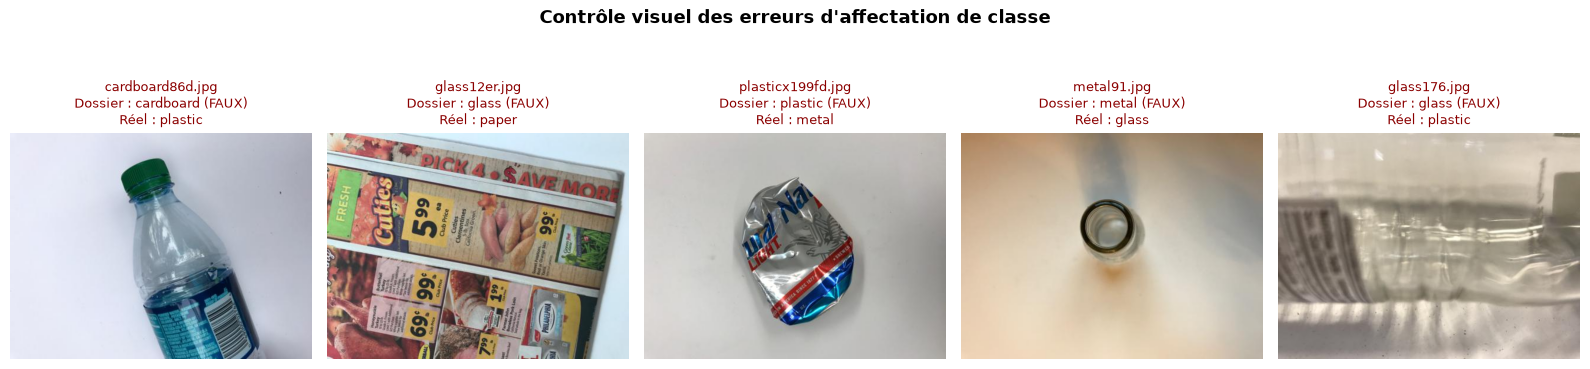

In [20]:
# Affichage visuel des 5 images mal classées
fig, axes = plt.subplots(1, len(images_suspectes), figsize=(16, 4))

for ax, img_info in zip(axes, images_suspectes):
    with Image.open(img_info['chemin']) as img:
        ax.imshow(img.convert('RGB'))

    titre = (
        f"{img_info['nom']}\n"
        f"Dossier : {img_info['dossier_actuel']} (FAUX)\n"
        f"Réel : {img_info['classe_reelle_observee']}"
    )
    ax.set_title(titre, fontsize=9, color='darkred' if img_info['dossier_actuel'] != img_info['classe_reelle_observee'] else 'green')
    ax.axis('off')

plt.suptitle("Contrôle visuel des erreurs d'affectation de classe", fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### Bilan de la Partie 7
Le contrôle visuel permet d'isoler formellement **5 images mal classées** dans le dataset d'origine :
1. `cardboard86d.jpg` : classée à tort en `cardboard` alors qu'il s'agit d'une bouteille en **plastique**.
2. `glass12er.jpg` : classée à tort en `glass` alors qu'il s'agit d'un prospectus en **papier**.
3. `plasticx199fd.jpg` : classée à tort en `plastic` alors qu'il s'agit d'une canette en **métal**.
4. `metal91.jpg` : classée à tort en `metal` alors qu'il s'agit d'une bouteille en **verre** (doublon avec `glass115.jpg`).
5. `glass176.jpg` : classée à tort en `glass` alors qu'il s'agit d'une bouteille en **plastique** (doublon avec `plastic152.jpg`).

Cette vérification confirme l'existence d'erreurs d'attribution sémantique qu'aucun filtre statistique automatisé n'aurait pu corriger seul.